# Experiment 1: Skill Frequency in Data Science Job Postings

Core skills such as Python, SQL, and statistics will have the highest frequency across job postings, indicating baseline requirements for data science roles -- does it supports by the real world data? 

This notebook tests the hypothesis that core skills such as Python, SQL, and statistics appear most frequently across data science job postings.


In [1]:
# !pip install pandas
# !pip install matplotlib
# !pip install mlxtend


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from helpers import parse_salary
from job_dataset_union import build_unified_jobs_df


In [3]:
data_paths = [
    # Dataset 1 
    Path("data/glassdoor_jobs_2023.csv"),
    # Dataset 2
    Path("data/data_science_job_posts_2025.csv"),
]

df = build_unified_jobs_df()

required_column = "job_description_skills"
if required_column not in df.columns:
    raise ValueError(f"Expected '{required_column}' column in the unified dataset.")

job_descriptions = df[required_column].fillna("").astype(str)
print(f"Loaded {len(df)} job postings from {', '.join(str(path) for path in data_paths)}.")
print(df['source_dataset'].value_counts())


Loaded 2444 job postings from data\glassdoor_jobs_2023.csv, data\data_science_job_posts_2025.csv.
source_dataset
glassdoor_2023                 1500
data_science_job_posts_2025     944
Name: count, dtype: int64


In [4]:
df.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
0,Data Scientist,Remote,Education,-1,Primary & Secondary Schools,Job Overview\nA Data Scientist at ExploreLearn...,glassdoor_2023,4.2,Cambium Learning Group\n4.3,1001 to 5000 Employees,...,Company - Private,$500 million to $1 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 University Graduate - Data Scientist,"San Jose, CA",Information Technology,Employer Provided Salary:$83K - $153K,Computer Hardware Development,Our Company\n\nChanging the world through digi...,glassdoor_2023,4.4,Adobe\n4.4,10000+ Employees,...,Company - Public,$5 to $10 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist – Entry Level 2024,"Atlanta, GA",Information Technology,Employer Provided Salary:$71K - $133K,Information Technology Support Services,Introduction\nRanked by Forbes as one of the w...,glassdoor_2023,3.9,IBM\n3.9,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist 2,"Redmond, WA",Information Technology,Employer Provided Salary:$94K - $183K,Computer Hardware Development,The Microsoft 365 team is looking for a Data S...,glassdoor_2023,4.3,Microsoft\n4.3,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entry Level Data Scientist 2023/2024,"The Woodlands, TX",Manufacturing,$48K - $78K (Glassdoor est.),Chemical Manufacturing,"You may not realize it, but you’ve likely used...",glassdoor_2023,3.9,CPChem\n3.9,1001 to 5000 Employees,...,Company - Private,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.tail()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
2439,data scientist,"Bengaluru, Karnataka, India",<NA>,"€33,288 - €53,080",Technology,"['pytorch', 'python', 'sql', 'machine learning...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,NaN,company_171,a day ago,"Armonk, NY, US",Public,"524,598",€120.29B
2440,machine learning engineer,"Melbourne, Victoria, Australia",<NA>,"€64,290",Retail,"['amazon', 'machine learning']",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,NaN,company_134,a month ago,"Seattle, WA, US",Public,"865,456",€838.78B
2441,data scientist,"McLean, VA",<NA>,"€145,904 - €166,510",Retail,"['spark', 'aws', 'r', 'python', 'scala', 'sql'...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,midlevel,on-site,company_395,11 days ago,"McLean, VA, US",Public,"55,150",€36.29B
2442,data scientist,"New York, NY",<NA>,"€159,149 - €181,595",Retail,"['spark', 'aws', 'r', 'python', 'scala', 'sql'...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,midlevel,on-site,company_395,17 days ago,"McLean, VA, US",Public,"55,110",€36.34B
2443,data scientist,"San Diego, CA",<NA>,"€195,486 - €201,926",Technology,"['r', 'python', 'scala', 'sql', 'machine learn...",data_science_job_posts_2025,NaN,NaN,NaN,...,NaN,NaN,senior,on-site,company_844,8 days ago,"Mountain View, CA, US",Public,"17,040",€95.22B


In [6]:
skill_patterns = {
    # Core programming / query
    "Python": r"\bpython\b",
    "R": r"(?<![A-Za-z0-9])r(?![A-Za-z0-9])|\br[- ]studio\b|\btidyverse\b",
    "SQL": r"\bsql\b|\bpostgresql\b|\bmysql\b|\btsql\b|\bt-sql\b|\bpl/sql\b",
    "SAS": r"\bsas\b",
    "Excel": r"\bexcel\b|\bmicrosoft excel\b|\bspreadsheets?\b",

    # Statistics / math / analytics
    "Statistics": r"\bstatistic(?:s|al)?\b|\bprobability\b|\bhypothesis testing\b|\bstatistical modeling\b",
    "A/B Testing": r"\ba/?b testing\b|\bexperiment(?:ation|s)?\b|\bmultivariate testing\b",
    "Regression": r"\bregression\b|\blinear regression\b|\blogistic regression\b",
    "Time Series": r"\btime series\b|\bforecasting\b|\barima\b|\bprophet\b",
    "Optimization": r"\boptimization\b|\blinear programming\b|\bconvex optimization\b",

    # ML / AI
    "Machine Learning": r"\bmachine learning\b|\bml\b",
    "Deep Learning": r"\bdeep learning\b|\bneural networks?\b|\bcnn\b|\brnn\b|\blstm\b|\btransformers?\b",
    "NLP": r"\bnlp\b|\bnatural language processing\b|\btext mining\b|\btext analytics\b",
    "Computer Vision": r"\bcomputer vision\b|\bimage processing\b|\bobject detection\b",
    "Generative AI": r"\bgenerative ai\b|\bgenai\b|\bllms?\b|\blarge language models?\b|\bfoundation models?\b",
    "Reinforcement Learning": r"\breinforcement learning\b|\brl\b",

    # ML libraries
    "Scikit-learn": r"\bscikit[- ]learn\b|\bsklearn\b",
    "TensorFlow": r"\btensorflow\b",
    "PyTorch": r"\bpytorch\b",
    "Keras": r"\bkeras\b",
    "XGBoost": r"\bxgboost\b",
    "LightGBM": r"\blightgbm\b",
    "CatBoost": r"\bcatboost\b",

    # Data manipulation / notebooks
    "Pandas": r"\bpandas\b",
    "NumPy": r"\bnumpy\b",
    "SciPy": r"\bscipy\b",
    "Jupyter": r"\bjupyter\b|\bjupyter notebook\b|\bnotebooks?\b",

    # Visualization / BI
    "Tableau": r"\btableau\b",
    "Power BI": r"\bpower bi\b|\bpowerbi\b",
    "Looker": r"\blooker\b|\blooker studio\b",
    "Matplotlib": r"\bmatplotlib\b",
    "Seaborn": r"\bseaborn\b",
    "Plotly": r"\bplotly\b",
    "Data Visualization": r"\bdata visualization\b|\bdata visualisation\b|\bdashboard(?:s)?\b",

    # Big data / distributed
    "Spark": r"\bspark\b|\bapache spark\b|\bpyspark\b",
    "Hadoop": r"\bhadoop\b",
    "Hive": r"\bhive\b",
    "Kafka": r"\bkafka\b|\bapache kafka\b",
    "Databricks": r"\bdatabricks\b",

    # Data engineering / orchestration
    "ETL": r"\betl\b|\belt\b|\bdata pipelines?\b",
    "Airflow": r"\bairflow\b|\bapache airflow\b",
    "dbt": r"\bdbt\b",
    "Snowflake": r"\bsnowflake\b",
    "Redshift": r"\bredshift\b",
    "BigQuery": r"\bbigquery\b|\bgoogle bigquery\b",

    # Cloud
    "AWS": r"\baws\b|\bamazon web services\b",
    "Azure": r"\bazure\b|\bmicrosoft azure\b",
    "GCP": r"\bgcp\b|\bgoogle cloud\b|\bgoogle cloud platform\b",

    # Databases / storage
    "NoSQL": r"\bnosql\b|\bmongodb\b|\bcassandra\b|\bdynamodb\b",
    "MongoDB": r"\bmongodb\b",
    "PostgreSQL": r"\bpostgresql\b|\bpostgres\b",
    "MySQL": r"\bmysql\b",

    # Software / deployment
    "Git": r"\bgit\b|\bgithub\b|\bgitlab\b",
    "Docker": r"\bdocker\b",
    "Kubernetes": r"\bkubernetes\b|\bk8s\b",
    "Linux": r"\blinux\b",
    "API": r"\bapi(?:s)?\b|\brest api(?:s)?\b",

    # Business / product-oriented analytics
    "Business Intelligence": r"\bbusiness intelligence\b|\bbi\b",
    "Data Mining": r"\bdata mining\b",
    "Feature Engineering": r"\bfeature engineering\b",
    "Model Deployment": r"\bmodel deployment\b|\bmodel serving\b|\bmachine learning ops\b|\bmlops\b",
    "Data Warehousing": r"\bdata warehouse\b|\bdata warehousing\b",

    # Common DS adjacent tools
    "PowerPoint": r"\bpowerpoint\b|\bmicrosoft powerpoint\b",
    "Communication": r"\bcommunication skills?\b|\bpresentation skills?\b|\bstakeholder management\b",
}

posting_count = len(job_descriptions)
frequency_rows = []

for skill, pattern in skill_patterns.items():
    mention_count = job_descriptions.str.contains(pattern, case=False, regex=True).sum()
    frequency_rows.append(
        {
            "Skill": skill,
            "Mention Count": int(mention_count),
            "Percentage of Postings": round(mention_count / posting_count * 100, 2),
        }
    )

skill_frequency = (
    pd.DataFrame(frequency_rows)
    .sort_values(by="Mention Count", ascending=False)
    .reset_index(drop=True)
)

skill_frequency

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,984,40.26
1,Python,796,32.57
2,SQL,533,21.81
3,R,449,18.37
4,Statistics,320,13.09
...,...,...,...
59,Kafka,1,0.04
60,MySQL,1,0.04
61,CatBoost,0,0.00
62,MongoDB,0,0.00


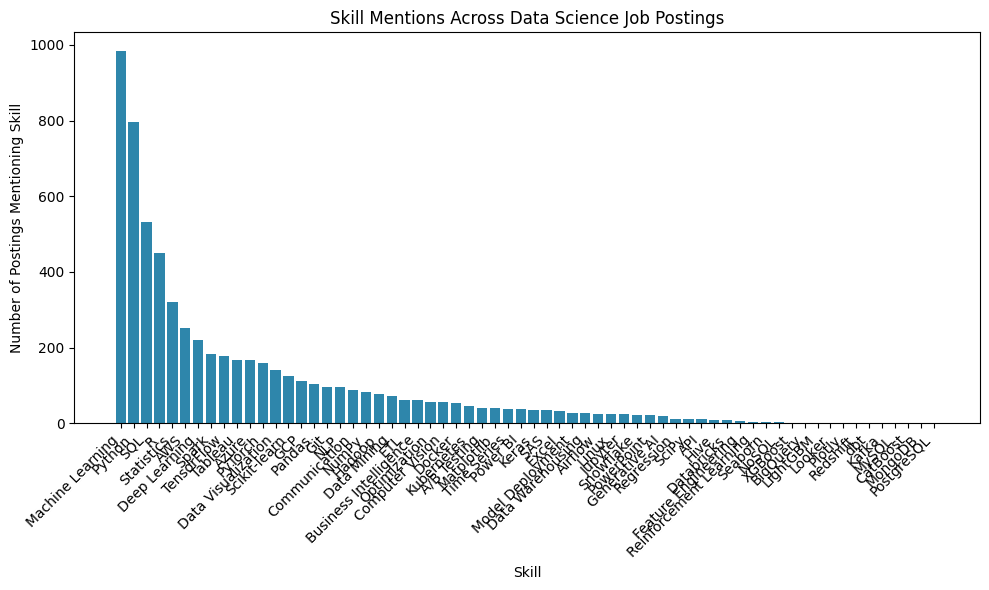

In [7]:
plt.figure(figsize=(10, 6))
plt.bar(skill_frequency["Skill"], skill_frequency["Mention Count"], color="#2E86AB")
plt.title("Skill Mentions Across Data Science Job Postings")
plt.xlabel("Skill")
plt.ylabel("Number of Postings Mentioning Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
core_skills = skill_frequency[skill_frequency["Skill"].isin(["Machine Learning", 
                                                             "Deep Learning",
                                                             "NLP",
                                                             "AWS",
                                                             "Python",
                                                             "SQL",
                                                             "Statistics"])]

core_skills

,Skill,Mention Count,Percentage of Postings
0,Machine Learning,984,40.26
1,Python,796,32.57
2,SQL,533,21.81
4,Statistics,320,13.09
5,AWS,253,10.35
6,Deep Learning,220,9.00
17,NLP,95,3.89


## Interpretation

The hypothesis is **partially supported** by this dataset. Statistics-related terms and Python are frequent baseline skills in data science postings, but SQL is not among the very highest-frequency mentions. Instead, machine learning appears most often in the job descriptions.

With the current data, the ranking is expected to look approximately like this:

- Machine Learning: 900+ postings
- Statistics: 300+ postings
- Python: 700+ postings
- SQL: 500+ postings

This suggests that Python and statistics are strong baseline requirements, while SQL remains important but less dominant than the original hypothesis predicted.

# Experiment 2: Skills and Associated Salary

Job postings requiring advanced skill bundles (e.g., machine learning, cloud platforms, big data tools) will be
associated with higher salary ranges.

In [9]:
# Check available columns and salary data
print("Columns in dataset:")
print(df.columns.tolist())
print("\n" + "="*50)
print("Salary-related columns:")
salary_cols = [col for col in df.columns if 'salary' in col.lower() or 'pay' in col.lower()]
print(salary_cols)
print("\nFirst few rows of salary data:")
if salary_cols:
    print(df[salary_cols].head(10))
else:
    print("No salary columns found. Showing all columns:")
    print(df.head())

Columns in dataset:
['job_title', 'location', 'sector', 'salary_range', 'industry', 'job_description_skills', 'source_dataset', 'Rating', 'Company Name', 'Size', 'Founded', 'Type of ownership', 'Revenue', 'seniority_level', 'status', 'company', 'post_date', 'headquarter', 'ownership', 'company_size', 'revenue']

Salary-related columns:
['salary_range']

First few rows of salary data:
                                        salary_range
0                                                 -1
1              Employer Provided Salary:$83K - $153K
2              Employer Provided Salary:$71K - $133K
3              Employer Provided Salary:$94K - $183K
4                       $48K - $78K (Glassdoor est.)
5  Employer Provided Salary:$65.00 - $75.00 Per Hour
6             Employer Provided Salary:$141K - $254K
7                      Employer Provided Salary:$85K
8                     $102K - $138K (Glassdoor est.)
9  Employer Provided Salary:$51.00 - $68.72 Per Hour


In [10]:
# Apply salary parsing
df['Salary_Numeric'] = df['salary_range'].apply(parse_salary)

# Remove rows with no valid salary data
df_with_salary = df[df['Salary_Numeric'].notna()].copy()

print(f"Rows with valid salary data: {len(df_with_salary)} out of {len(df)}")
print(f"\nSalary statistics (in dollars):")
print(df_with_salary['Salary_Numeric'].describe())
print(f"\nSalary statistics (in thousands):")
print(df_with_salary['Salary_Numeric'].describe() / 1000)


Rows with valid salary data: 2069 out of 2444

Salary statistics (in dollars):
count    2.069000e+03
mean     1.358756e+05
std      9.747587e+04
min      2.035575e+04
25%      1.020000e+05
50%      1.255000e+05
75%      1.650000e+05
max      2.986577e+06
Name: Salary_Numeric, dtype: float64

Salary statistics (in thousands):
count       2.069000
mean      135.875637
std        97.475872
min        20.355750
25%       102.000000
50%       125.500000
75%       165.000000
max      2986.577110
Name: Salary_Numeric, dtype: float64


In [11]:
# Data-driven skill bundle discovery and salary analysis
import re
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder

# Extract skills present in each job description
skill_lists = []
for desc in job_descriptions:
    skills_present = []
    for skill, pattern in skill_patterns.items():
        if re.search(pattern, desc, re.IGNORECASE):
            skills_present.append(skill)
    skill_lists.append(skills_present)

# Create transaction encoder
te = TransactionEncoder()
te_ary = te.fit(skill_lists).transform(skill_lists)
skill_df = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets with minimum support.
# Lowered after the dataset union so rare but high-value bundles still survive the larger denominator.
frequent_itemsets = apriori(skill_df, min_support=0.019, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Filter for bundles (2+ skills)
bundle_itemsets = frequent_itemsets[frequent_itemsets['length'] >= 2].sort_values('support', ascending=False)

print("Data-driven skill bundles discovered:")
print(f"Total bundles found: {len(bundle_itemsets)}")
print(bundle_itemsets.head(10))

# Analyze salaries for each bundle
bundle_salary_data = []
for idx, row in bundle_itemsets.iterrows():
    bundle = row['itemsets']
    support = row['support']
    
    # Find jobs that have ALL skills in this bundle
    matching_jobs = []
    for i, skills in enumerate(skill_lists):
        if bundle.issubset(set(skills)):
            matching_jobs.append(i)
    
    # Filter to jobs with salary data
    salary_jobs = df_with_salary[df_with_salary.index.isin(matching_jobs)]
    
    if len(salary_jobs) > 0:
        avg_salary = salary_jobs['Salary_Numeric'].mean()
        min_salary = salary_jobs['Salary_Numeric'].min()
        max_salary = salary_jobs['Salary_Numeric'].max()
        count = len(salary_jobs)
        pct_of_salary_jobs = (count / len(df_with_salary)) * 100
        
        bundle_salary_data.append({
            'Skill Bundle': ', '.join(sorted(bundle)),
            'Support (%)': round(support * 100, 1),
            'Count': count,
            '% of Salary Jobs': round(pct_of_salary_jobs, 1),
            'Avg Salary ($K)': round(avg_salary / 1000, 1),
            'Min ($K)': round(min_salary / 1000, 1),
            'Max ($K)': round(max_salary / 1000, 1),
        })

# Create DataFrame and sort by average salary
bundle_analysis_df = pd.DataFrame(bundle_salary_data).sort_values('Avg Salary ($K)', ascending=False)

# Filter out bundles with only 1 matching job posting
bundle_analysis_df = bundle_analysis_df[bundle_analysis_df['Count'] > 1]

print("\nData-driven skill bundles sorted by highest average salary:")
print(bundle_analysis_df.head(15).to_string(index=False))

overall_avg_salary = df_with_salary['Salary_Numeric'].mean() / 1000
print(f"\nOverall average salary: ${overall_avg_salary:.1f}K")
print(f"Total bundles analyzed: {len(bundle_analysis_df)}")
print(f"Bundles with premium salaries (>${overall_avg_salary + 10:.1f}K): {len(bundle_analysis_df[bundle_analysis_df['Avg Salary ($K)'] > overall_avg_salary + 10])}")

Data-driven skill bundles discovered:
Total bundles found: 310
      support                                    itemsets  length
84   0.244681       frozenset({Machine Learning, Python})       2
106  0.200491                    frozenset({SQL, Python})       2
105  0.164075                      frozenset({R, Python})       2
86   0.154664          frozenset({SQL, Machine Learning})       2
212  0.151800  frozenset({SQL, Machine Learning, Python})       3
85   0.132160            frozenset({R, Machine Learning})       2
211  0.128069    frozenset({R, Machine Learning, Python})       3
112  0.124386                         frozenset({SQL, R})       2
242  0.115385                 frozenset({SQL, R, Python})       3
32   0.090835                    frozenset({Python, AWS})       2

Data-driven skill bundles sorted by highest average salary:
                             Skill Bundle  Support (%)  Count  % of Salary Jobs  Avg Salary ($K)  Min ($K)  Max ($K)
                  AWS, Python, SQ

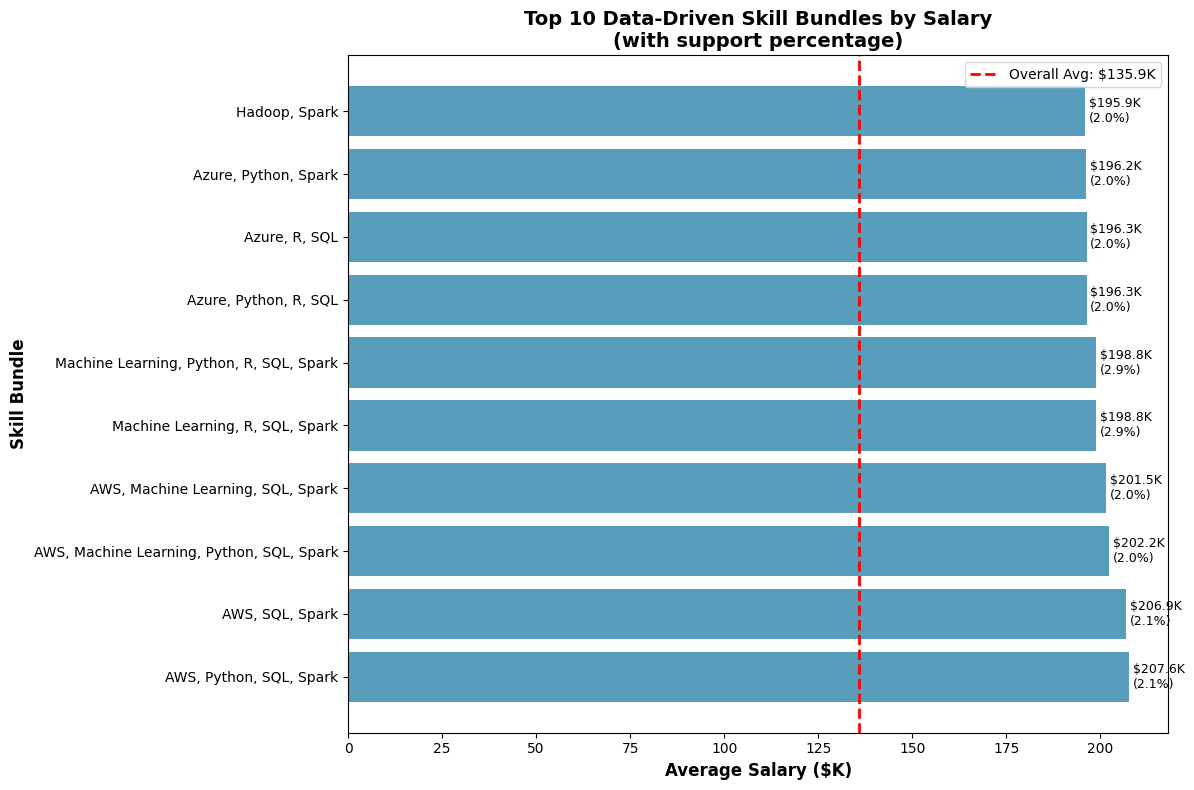


KEY FINDINGS:

✓ Highest-paying bundle: AWS, Python, SQL, Spark
  Average: $207.6K
  Salary range: $24.1K - $2986.6K
  Found in 51 postings (2.5%)

✓ Premium skill bundles (>$145.9K):
  - AWS, Python, SQL, Spark: $207.6K (+52.8%)
  - AWS, SQL, Spark: $206.9K (+52.3%)
  - AWS, Machine Learning, Python, SQL, Spark: $202.2K (+48.8%)
  - AWS, Machine Learning, SQL, Spark: $201.5K (+48.3%)
  - Machine Learning, Python, R, SQL, Spark: $198.8K (+46.3%)


In [12]:
# Visualization of top data-driven skill bundles vs salary
fig, ax = plt.subplots(figsize=(12, 8))

# Get top 10 bundles by salary
top_bundles = bundle_analysis_df.head(10).sort_values('Avg Salary ($K)', ascending=True)

# Create horizontal bar chart
bars = ax.barh(top_bundles['Skill Bundle'], top_bundles['Avg Salary ($K)'], 
               color='#2E86AB', alpha=0.8)

# Add overall average line
overall_avg = df_with_salary['Salary_Numeric'].mean() / 1000
ax.axvline(overall_avg, color='red', linestyle='--', linewidth=2, 
           label=f'Overall Avg: ${overall_avg:.1f}K')

# Add support percentage as text
for i, (idx, row) in enumerate(top_bundles.iterrows()):
    ax.text(row['Avg Salary ($K)'] + 1, i, 
            f"${row['Avg Salary ($K)']:.1f}K\n({row['Support (%)']}%)", 
            va='center', fontsize=9)

ax.set_xlabel('Average Salary ($K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Skill Bundle', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Data-Driven Skill Bundles by Salary\n(with support percentage)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()  # Highest at top

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)
highest_bundle = bundle_analysis_df.iloc[0]
print(f"\n✓ Highest-paying bundle: {highest_bundle['Skill Bundle']}")
print(f"  Average: ${highest_bundle['Avg Salary ($K)']:.1f}K")
print(f"  Salary range: ${highest_bundle['Min ($K)']:.1f}K - ${highest_bundle['Max ($K)']:.1f}K")
print(f"  Found in {highest_bundle['Count']} postings ({highest_bundle['% of Salary Jobs']:.1f}%)")

premium_bundles = bundle_analysis_df[bundle_analysis_df['Avg Salary ($K)'] > overall_avg + 10]
if len(premium_bundles) > 0:
    print(f"\n✓ Premium skill bundles (>${overall_avg+10:.1f}K):")
    for idx, row in premium_bundles.head(5).iterrows():
        premium_pct = ((row['Avg Salary ($K)'] - overall_avg) / overall_avg) * 100
        print(f"  - {row['Skill Bundle']}: ${row['Avg Salary ($K)']:.1f}K (+{premium_pct:.1f}%)")